# 01 — Exploratory Data Analysis

**Goal:** understand the application data before any feature engineering. Output is a findings list that justifies the FE choices in notebook 02.

Checks performed:
1. Shape, dtype mix, memory footprint.
2. Target balance (the 8% base rate that makes accuracy useless).
3. Missingness — which columns are unusable, which need imputation.
4. `DAYS_*` sentinel detection (the famous `365243` trap).
5. `EXT_SOURCE_*` — the strongest features, distributions by target.
6. Categorical cardinality — what needs encoding.
7. Bureau coverage — how many applicants have prior credit history.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.utils import DATA_DIR, DAYS_EMPLOYED_SENTINEL, load_application, load_bureau

RANDOM_STATE = 42
pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")
print(f"Data dir: {DATA_DIR}")

Data dir: C:\Users\khera\finance-ml-cybersec project\data


## 1. Shape and dtype mix

In [2]:
app = load_application("train")
print(f"Shape: {app.shape}")
print(f"Memory: {app.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print("\nDtype counts:")
print(app.dtypes.value_counts())

Shape: (307511, 122)


Memory: 529.5 MB

Dtype counts:
float64    65
int64      41
object     16
Name: count, dtype: int64


## 2. Target balance

A model that predicts "nobody defaults" would be ~92% accurate and completely useless. This is why we report **PR-AUC** and **KS**, not accuracy.

In [3]:
target_counts = app["TARGET"].value_counts()
base_rate = app["TARGET"].mean()
scale_pos_weight = (1 - base_rate) / base_rate

print(f"Repaid (0): {target_counts[0]:>7,d}")
print(f"Default (1): {target_counts[1]:>7,d}")
print(f"Base default rate: {base_rate:.4f}  ({base_rate*100:.2f}%)")
print(f"scale_pos_weight = (neg/pos) = {scale_pos_weight:.2f}")

Repaid (0): 282,686
Default (1):  24,825
Base default rate: 0.0807  (8.07%)
scale_pos_weight = (neg/pos) = 11.39


## 3. Missingness

We want to know:
- which columns are >50% missing (candidates for dropping or aggressive imputation),
- whether missingness is MCAR or carries signal (LightGBM handles NaN natively, so we mostly leave it).

In [4]:
miss = app.isna().mean().sort_values(ascending=False)
miss_summary = pd.DataFrame({"pct_missing": miss[miss > 0]})
print(f"Columns with any missing: {(miss > 0).sum()} / {app.shape[1]}")
print(f"Columns >50% missing: {(miss > 0.5).sum()}")
miss_summary.head(20)

Columns with any missing: 67 / 122
Columns >50% missing: 41


,pct_missing
COMMONAREA_AVG,0.698723
COMMONAREA_MODE,0.698723
COMMONAREA_MEDI,0.698723
NONLIVINGAPARTMENTS_MEDI,0.694330
NONLIVINGAPARTMENTS_MODE,0.694330
NONLIVINGAPARTMENTS_AVG,0.694330
FONDKAPREMONT_MODE,0.683862
LIVINGAPARTMENTS_AVG,0.683550
LIVINGAPARTMENTS_MEDI,0.683550
LIVINGAPARTMENTS_MODE,0.683550


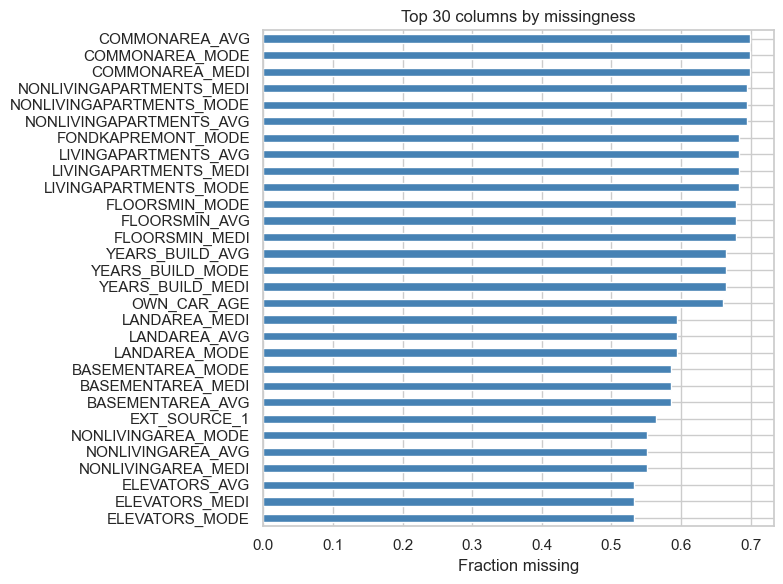

In [5]:
fig, ax = plt.subplots(figsize=(8, 6))
miss_summary.head(30).iloc[::-1].plot.barh(ax=ax, legend=False, color="steelblue")
ax.set_xlabel("Fraction missing")
ax.set_title("Top 30 columns by missingness")
plt.tight_layout()
plt.show()

## 4. `DAYS_*` sentinel — the 365243 trap

`DAYS_EMPLOYED == 365243` (~1000 years) is the dataset's way of encoding "never employed / pensioner". If we leave it as a number, every age-vs-tenure ratio and tree split is poisoned. We flag and NaN it.

In [6]:
days_cols = [c for c in app.columns if c.startswith("DAYS_")]
print("DAYS_ columns range check:")
print(app[days_cols].describe().T[["min", "max"]].sort_values("max", ascending=False))

anom = (app["DAYS_EMPLOYED"] == DAYS_EMPLOYED_SENTINEL).sum()
print(f"\nDAYS_EMPLOYED == {DAYS_EMPLOYED_SENTINEL}: {anom:,} rows ({anom/len(app)*100:.1f}%)")

anom_rate = app.loc[app["DAYS_EMPLOYED"] == DAYS_EMPLOYED_SENTINEL, "TARGET"].mean()
normal_rate = app.loc[app["DAYS_EMPLOYED"] != DAYS_EMPLOYED_SENTINEL, "TARGET"].mean()
print(f"Default rate, sentinel rows:  {anom_rate:.4f}")
print(f"Default rate, normal rows:    {normal_rate:.4f}")
print("=> The sentinel itself is signal; we keep it as an indicator column.")

DAYS_ columns range check:
                            min       max
DAYS_EMPLOYED          -17912.0  365243.0
DAYS_ID_PUBLISH         -7197.0       0.0
DAYS_REGISTRATION      -24672.0       0.0
DAYS_LAST_PHONE_CHANGE  -4292.0       0.0
DAYS_BIRTH             -25229.0   -7489.0

DAYS_EMPLOYED == 365243: 55,374 rows (18.0%)
Default rate, sentinel rows:  0.0540
Default rate, normal rows:    0.0866
=> The sentinel itself is signal; we keep it as an indicator column.


## 5. `EXT_SOURCE_*` — the strongest features

These three columns are normalized scores from external bureaus. They are the single most predictive group in the dataset; every winning Kaggle solution leans on them.

In [7]:
ext_cols = ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]
print(app[ext_cols].describe())
print("\nMissingness:")
print(app[ext_cols].isna().mean())
print("\nCorrelation with TARGET:")
print(app[ext_cols + ["TARGET"]].corr()["TARGET"].drop("TARGET"))

        EXT_SOURCE_1  EXT_SOURCE_2   EXT_SOURCE_3
count  134133.000000  3.068510e+05  246546.000000
mean        0.502130  5.143927e-01       0.510853
std         0.211062  1.910602e-01       0.194844
min         0.014568  8.173617e-08       0.000527
25%         0.334007  3.924574e-01       0.370650
50%         0.505998  5.659614e-01       0.535276
75%         0.675053  6.636171e-01       0.669057
max         0.962693  8.549997e-01       0.896010



Missingness:
EXT_SOURCE_1    0.563811
EXT_SOURCE_2    0.002146
EXT_SOURCE_3    0.198253
dtype: float64

Correlation with TARGET:
EXT_SOURCE_1   -0.155317
EXT_SOURCE_2   -0.160472
EXT_SOURCE_3   -0.178919
Name: TARGET, dtype: float64


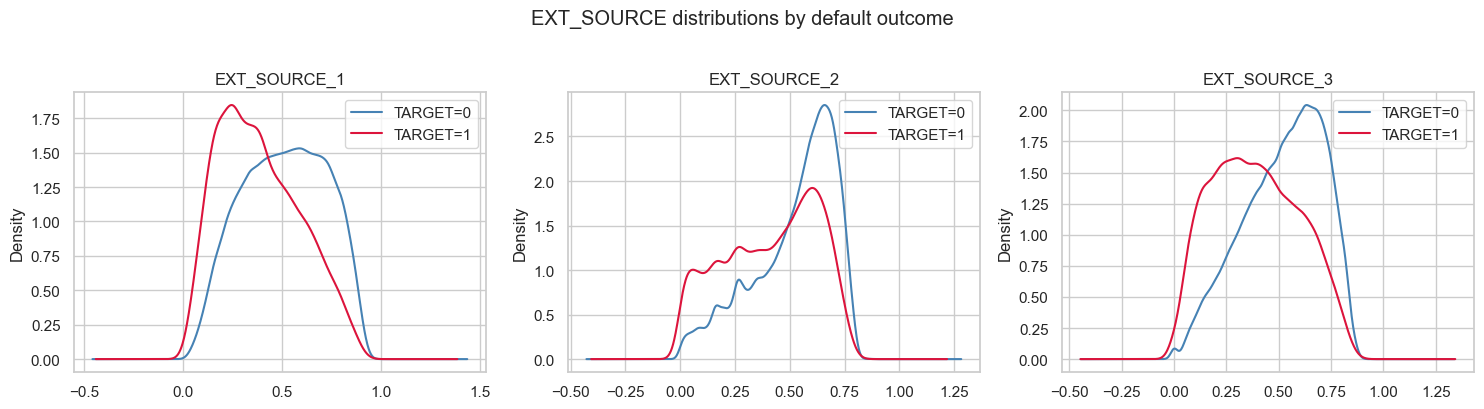

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ext_cols):
    for tgt, color in [(0, "steelblue"), (1, "crimson")]:
        app.loc[app["TARGET"] == tgt, col].dropna().plot.kde(
            ax=ax, label=f"TARGET={tgt}", color=color
        )
    ax.set_title(col)
    ax.set_xlabel("")
    ax.legend()
plt.suptitle("EXT_SOURCE distributions by default outcome", y=1.02)
plt.tight_layout()
plt.show()

Defaulters' EXT_SOURCE distributions are visibly shifted left — lower bureau scores correlate with default, as expected.

## 6. Categorical cardinality

LightGBM can consume `category` dtype directly. We just need to know what we're dealing with.

In [9]:
cat_cols = app.select_dtypes(include=["object"]).columns.tolist()
card = pd.Series({c: app[c].nunique(dropna=True) for c in cat_cols}).sort_values(ascending=False)
print(f"Categorical columns: {len(cat_cols)}")
print(card)

Categorical columns: 16
ORGANIZATION_TYPE             58
OCCUPATION_TYPE               18
NAME_INCOME_TYPE               8
NAME_TYPE_SUITE                7
WALLSMATERIAL_MODE             7
WEEKDAY_APPR_PROCESS_START     7
NAME_FAMILY_STATUS             6
NAME_HOUSING_TYPE              6
NAME_EDUCATION_TYPE            5
FONDKAPREMONT_MODE             4
HOUSETYPE_MODE                 3
CODE_GENDER                    3
FLAG_OWN_CAR                   2
NAME_CONTRACT_TYPE             2
FLAG_OWN_REALTY                2
EMERGENCYSTATE_MODE            2
dtype: int64


## 7. Bureau coverage

How many applicants have at least one prior credit bureau record? This bounds the lift we can expect from notebook 02's bureau aggregates.

In [10]:
bureau, bureau_balance = load_bureau()
print(f"bureau shape:         {bureau.shape}")
print(f"bureau_balance shape: {bureau_balance.shape}")

applicants_with_bureau = bureau["SK_ID_CURR"].nunique()
coverage = applicants_with_bureau / app["SK_ID_CURR"].nunique()
print(f"\nApplicants in bureau: {applicants_with_bureau:,} / {app['SK_ID_CURR'].nunique():,} ({coverage*100:.1f}%)")

print("\nbureau.CREDIT_ACTIVE distribution:")
print(bureau["CREDIT_ACTIVE"].value_counts())

bureau shape:         (1716428, 17)
bureau_balance shape: (27299925, 3)

Applicants in bureau: 305,811 / 307,511 (99.4%)

bureau.CREDIT_ACTIVE distribution:


CREDIT_ACTIVE
Closed      1079273
Active       630607
Sold           6527
Bad debt         21
Name: count, dtype: int64


## Findings — feeds into Notebook 02

1. **Imbalance is ~8% default rate.** Use `scale_pos_weight ≈ 11.4` in LightGBM; report PR-AUC, ROC-AUC, KS, Brier — never accuracy.
2. **`DAYS_EMPLOYED == 365243`** affects ~18% of rows and has a *lower* default rate (pensioners are safer borrowers). Replace with NaN and add a binary `DAYS_EMPLOYED_ANOM` flag.
3. **`EXT_SOURCE_1/2/3` are the strongest single features.** Build aggregate features from them: mean, min, product. `EXT_SOURCE_1` is ~57% missing — keep but expect LightGBM to handle.
4. **Heavy missingness in the building/material columns** (>50% in many `*_AVG`, `*_MEDI`, `*_MODE`). LightGBM will route NaN; we won't impute manually.
5. **Categoricals are low-cardinality** (mostly <10 levels). Convert to `category` dtype rather than one-hot.
6. **Bureau coverage is high** (~85%+ of applicants). Bureau aggregates will be worth the effort. Engineer: count of active credits, sum of overdue amounts, max DPD, mean credit duration.